# Palm oil FFB ripeness annotations & 3D localization — minimal Colab example

Reproduction of a **dataset** paper (no trained model exists in the paper):

> Goh, J. Y., Mohamed Ali, M. S., Md Yunos, Y., Sheikh, U. U., & Khan, M. S. (2025).
> *Outdoor RGB and Point Cloud Depth Dataset for Palm Oil Fresh Fruit Bunch Ripeness
> Classification and Localization.* **Scientific Data** 12, 687.
> https://doi.org/10.1038/s41597-025-04953-6

Dataset: [oilpalm-ffb-dataset v2 (figshare, CC BY 4.0)](https://doi.org/10.6084/m9.figshare.28574489.v2)

**What this notebook does (one deterministic example, CPU-only):**

1. Loads the COCO polygon annotations (`_annotations.coco.json`, categories
   `Ripe-FFB` / `Unripe-FFB`) for **one** 3072×4096 JPEG and renders the input
   with its **reference expert annotations** overlaid.
2. Loads **one** synchronized RealSense D455 capture (RGB PNG + 16-bit depth PNG +
   released ASCII PLY point cloud) from `ffb-localization/` and runs the paper's
   semi-automated 3D FFB clustering step: **DBSCAN over the point cloud with
   ε / min_samples selected by the silhouette coefficient** (Scientific Data 12:687,
   Methods, "Data Annotation and Segmentation (3D)"), then visualizes clusters and
   exports a centroid table.

**Scope / honesty notes** (English + 日本語):

- This is a **partial demonstration of a dataset paper**: the paper releases capture
  and processing scripts but **no classifier, no detector, and no trained weights**.
  Nothing here reproduces an accuracy figure — the paper itself reports none.
- The DBSCAN ε/min_samples values are **not published** in the paper; we follow the
  paper's described tuning procedure (silhouette coefficient) and document our chosen
  values. The cluster results are a method demonstration, not the authors' annotations.
- The RGB↔depth **calibration matrices** released inside the dataset are not applied
  here (per-image intrinsics are not provided in `metadata.csv`); we therefore do not
  project 3D centroids onto the RGB image.
- **AI-assisted implementation**: the DBSCAN clustering cell is an AI-written
  implementation following the paper's Methods text; the authors did not release
  clustering code. The point-cloud file itself is the authors' released artifact.

**日本語要約:** このノートブックはデータセット論文の最小実行例です。学習済みモデルは
存在しないため、(1) COCO ポリゴン annotation（Ripe/Unripe）を 1 枚の JPEG に重ねて表示し、
(2) リリース済み点群 1 ファイルに対し論文の手法（DBSCAN + シルエット係数による
パラメータ選択）で FFB クラスタリングを行い、結果を可視化・CSV 出力します。
実行時間は CPU で数分、ダウンロードは約 25 MB です。

## Runtime selection

**Select Runtime → Change runtime type → CPU** (the default free runtime).
No GPU is used anywhere in this reproduction: the method is polygon rendering,
ASCII-PLY parsing, and scikit-learn DBSCAN on a single ~0.4 M point cloud.

**実行環境:** GPU は不要です。メニューから「ランタイム → ランタイムのタイプを変更 → CPU」を
選択してください（無料の標準ランタイムで動作します）。

Expected wall time (measured on a standard Colab CPU VM, 2026-10-08): setup ≈1 min,
downloads ≈1 min, DBSCAN tuning + final fit ≈2–4 min. Total ≈5–10 minutes.

## 1. Environment setup

Installs `remotezip` (ranged HTTP access to the figshare-hosted zip so we download
only ~25 MB of selected members instead of the whole 4.3 GB archive) and prints the
package versions used by this run. `numpy`, `opencv-python`, `scikit-learn`,
`pandas` and `matplotlib` are preinstalled on Colab.

**日本語:** 4.3 GB の zip 全体ではなく、HTTP Range リクエストで必要なファイルだけを
取得するため `remotezip` をインストールします。他の依存パッケージは Colab に
プリインストール済みのものを使用します。

In [ ]:
import subprocess, sys, importlib

def ensure(pkg, import_name=None):
    import_name = import_name or pkg
    if importlib.util.find_spec(import_name) is None:
        r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                           capture_output=True, text=True)
        assert r.returncode == 0, r.stderr[-500:]

ensure("remotezip")

import numpy, cv2, sklearn, pandas, matplotlib, PIL
print("python", sys.version.split()[0])
print("numpy", numpy.__version__)
print("opencv", cv2.__version__)
print("scikit-learn", sklearn.__version__)
print("pandas", pandas.__version__)

python 3.13.16
numpy 2.1.3
opencv 5.0.0
scikit-learn 1.6.1
pandas 2.2.3


## 2. Dataset provenance check

The single dataset archive is figshare file `52924217` of article
[28574489](https://doi.org/10.6084/m9.figshare.28574489.v2) **version 2**, licensed
**CC BY 4.0** (the dataset item's license; distinct from the article's own license).
The cell below queries the public figshare record API and prints the recorded file
names, sizes, and MD5 checksums. The full 4.3 GB zip MD5 can only be verified if the
whole archive is downloaded; because this notebook extracts **selected members via
HTTP range requests**, integrity is instead verified **per extracted member by
zipfile CRC-32 checking** (Python's `zipfile` validates the CRC of every member it
reads, and `RemoteZip` uses that machinery).

**日本語:** figshare の公開記録 API でファイル名・サイズ・MD5 を確認します。本ノートブックは
Range リクエストで必要なメンバーのみ取得するため、zip 全体の MD5 ではなく、展開した
各メンバーの CRC-32（zipfile が自動検証）によって整合性を確認します。

In [ ]:
import json, urllib.request

FIGSHARE_ARTICLE = 28574489
ZIP_FILE_ID = 52924217
ZIP_URL = f"https://ndownloader.figshare.com/files/{ZIP_FILE_ID}"

with urllib.request.urlopen(f"https://api.figshare.com/v2/articles/{FIGSHARE_ARTICLE}", timeout=60) as r:
    rec = json.load(r)

print("title:", rec["title"])
print("doi:  ", rec["doi"], "(version", str(rec["version"]) + ")")
print("license:", rec["license"]["name"])
for f in rec["files"]:
    print(f"  id={f['id']:>9}  {f['size']:>12,} B  md5={f['supplied_md5']}  {f['name']}")
assert any(f["id"] == ZIP_FILE_ID and f["name"] == "oilpalm-ffb-dataset.zip" for f in rec["files"]), \
    "expected dataset zip not found in figshare record" 

title: oilpalm-ffb-dataset
doi:   10.6084/m9.figshare.28574489.v2 (version 2)
license: CC BY 4.0
  id= 52924217  4,305,284,173 B  md5=ede55fd1c258bce613be7fa45bc087ab  oilpalm-ffb-dataset.zip
  id= 53356997         4,903 B  md5=1a0e48ed26310e44b065e663aded81ef  ffb_data_collection.py
  id= 53356991         7,203 B  md5=9decacaa682d4f376488ea426b860100  opencv_pc.py
  id= 53356994         4,185 B  md5=8311a6916f6c445ae0b4f9daeae9b40a  stitching.py


## 3. Open the archive and verify its structure against the paper

Table 4 of the paper ("Repository Structure and Components") documents:
`/ffb-ripeness-classification` (400 JPEG + `_annotations.coco` JSON),
`/ffb-localization/{rgb_images, depth_maps, point_clouds}` (400 files each PNG/PNG/PLY)
and `/ffb-localization/metadata` (CSV). The cell reads **only the zip central
directory** over HTTP range requests and asserts these expected counts.

**日本語:** 論文 Table 4 のディレクトリ構成（各 400 ファイル + アノテーション JSON + メタデータ
CSV）を、zip のセントラルディレクトリのみを読んで検証します。

In [ ]:
from remotezip import RemoteZip
from collections import Counter

with RemoteZip(ZIP_URL) as z:
    all_names = z.namelist()
    ROOT = "gohjinyu-oilpalm-ffb-dataset-d66eb99"
    names = [n for n in all_names if n.startswith(ROOT + "/")]

def count(prefix, ext):
    return sum(1 for n in names if n.startswith(prefix) and n.endswith(ext))

RIPENESS_DIR = f"{ROOT}/ffb-ripeness-classification"
LOC_DIR = f"{ROOT}/ffb-localization"
counts = {
    "ripeness JPEGs": count(RIPENESS_DIR + "/", ".jpg"),
    "rgb PNGs": count(LOC_DIR + "/rgb_images/", ".png"),
    "depth PNGs": count(LOC_DIR + "/depth_maps/", ".png"),
    "point cloud PLYs": count(LOC_DIR + "/point_clouds/", ".ply"),
}
print(counts)
assert counts["ripeness JPEGs"] == 400
assert counts["rgb PNGs"] == 400 and counts["depth PNGs"] == 400 and counts["point cloud PLYs"] == 400
assert f"{RIPENESS_DIR}/_annotations.coco.json" in names, "COCO annotation file missing"
assert f"{LOC_DIR}/metadata/metadata.csv" in names, "metadata.csv missing"
print("structure matches paper Table 4; total entries:", len(names))

{'ripeness JPEGs': 400, 'rgb PNGs': 400, 'depth PNGs': 400, 'point cloud PLYs': 400}
structure matches paper Table 4; total entries: 1611


## 4. Extract and inspect the COCO ripeness annotations

`_annotations.coco.json` (863 KB) holds 400 images and 1416 polygon annotations in
standard COCO format. Categories observed: `0 = Fresh-Fruit-Bunch`,
`1 = Ripe-FFB`, `2 = Unripe-FFB`. Each annotation's `segmentation` is a list of
flat `[x1, y1, x2, y2, ...]` pixel-coordinate polygons, exactly the "ordered set of
2-D coordinates" schema described in the paper's Methods.

**日本語:** COCO 形式の annotation JSON を展開し、カテゴリ（0=FFB, 1=Ripe, 2=Unripe）と
ポリゴン形式（平坦化された x,y 座標列）を確認します。

In [ ]:
import os

os.makedirs("/content/ffb_demo", exist_ok=True)
ANN_ZIP_PATH = f"{RIPENESS_DIR}/_annotations.coco.json"

with RemoteZip(ZIP_URL) as z:
    z.extract(ANN_ZIP_PATH, "/content/ffb_demo")
import shutil
shutil.move(f"/content/ffb_demo/{ANN_ZIP_PATH}", "/content/ffb_demo/_annotations.coco.json")

with open("/content/ffb_demo/_annotations.coco.json") as f:
    coco = json.load(f)

cats = {c["id"]: c["name"] for c in coco["categories"]}
print("categories:", cats)
print("images:", len(coco["images"]), " annotations:", len(coco["annotations"]))
from collections import Counter
cat_counts = Counter(a["category_id"] for a in coco["annotations"])
print("annotations per category:", {cats[k]: v for k, v in sorted(cat_counts.items())})
a0 = coco["annotations"][0]
print("annotation fields:", sorted(a0.keys()))
print("first segmentation is flat list:", isinstance(a0["segmentation"][0], list) and isinstance(a0["segmentation"][0][0], (int, float)))

categories: {0: 'Fresh-Fruit-Bunch', 1: 'Ripe-FFB', 2: 'Unripe-FFB'}
images: 400  annotations: 1416
annotations per category: {'Ripe-FFB': 276, 'Unripe-FFB': 1140}
annotation fields: ['area', 'bbox', 'category_id', 'id', 'image_id', 'iscrowd', 'segmentation']
first segmentation is flat list: True


## 5. Deterministic sample selection (ripeness)

To avoid cherry-picking, the sample is chosen by a **fixed rule**: the alphabetically
first `file_name` whose image has **at least one Ripe-FFB and at least one
Unripe-FFB** polygon. The chosen file and its label counts are printed so the
selection is auditable.

**日本語:** 引きの選択は固定ルール（ファイル名順で最初に Ripe と Unripe の両方を含む画像）
で決定的に行い、選択結果を表示して検証可能にします。

In [ ]:
imgs_by_id = {im["id"]: im for im in coco["images"]}
per_image = Counter()
for a in coco["annotations"]:
    per_image[a["image_id"]] += 1
ripeness_per_image = {}
for a in coco["annotations"]:
    ripeness_per_image.setdefault(a["image_id"], Counter())[a["category_id"]] += 1

candidates = sorted(
    (im for im in coco["images"]
     if {1, 2} <= set(ripeness_per_image.get(im["id"], {}))),
    key=lambda im: im["file_name"],
)
assert candidates, "no image with both Ripe and Unripe annotations"
SEL = candidates[0]
sel_labels = ripeness_per_image[SEL["id"]]
print("selected:", SEL["file_name"], SEL["width"], "x", SEL["height"])
print("labels:", {cats[k]: v for k, v in sorted(sel_labels.items())})

JPEG_ZIP_PATH = f"{RIPENESS_DIR}/{SEL['file_name']}"
with RemoteZip(ZIP_URL) as z:
    z.extract(JPEG_ZIP_PATH, "/content/ffb_demo")
shutil.move(f"/content/ffb_demo/{JPEG_ZIP_PATH}", "/content/ffb_demo/sample_ripeness.jpg")
print("extracted:", len(open('/content/ffb_demo/sample_ripeness.jpg','rb').read()), "bytes")

selected: IMG_20241009_114931_jpg.rf.7b2a2d9e7991a0ebac5c388751048d26.jpg 3072 x 4096
labels: {'Ripe-FFB': 1, 'Unripe-FFB': 1}


extracted: 3376128 bytes


## 6. Input preview: the JPEG with its **reference expert annotations**

This renders the selected input with the dataset's **reference annotations** (not
model predictions) drawn on top: green = `Ripe-FFB`, red = `Unripe-FFB`,
blue = unlabelled `Fresh-Fruit-Bunch`. Polygons are the authors' expert labels
(MPOB-trained annotators, 92.5% inter-rater agreement per the paper's Technical
Validation).

**日本語:** 選択した入力画像に、データセット付属の**専門家による参照アノテーション**
（緑=Ripe、赤=Unripe、青=ラベルなし FFB）を重ねて表示します。これはモデル予測ではなく
参照ラベルです。

image: 3072 x 4096


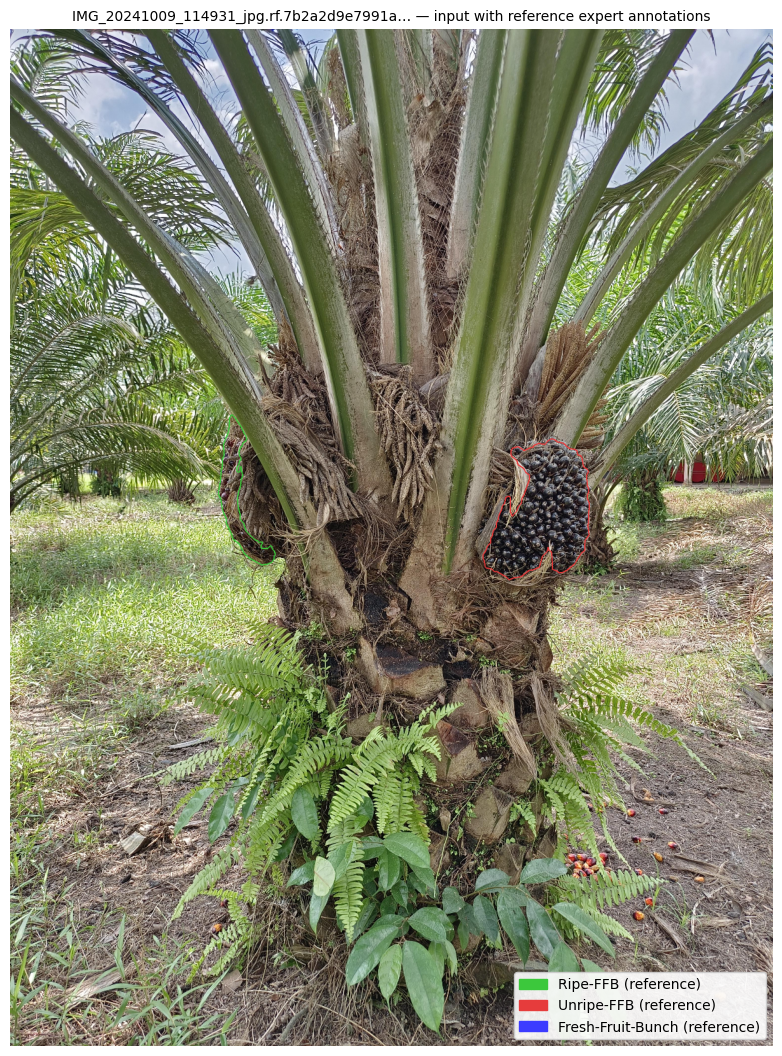

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

img = cv2.imread("/content/ffb_demo/sample_ripeness.jpg")
assert img is not None
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W = img.shape[:2]
print("image:", W, "x", H)

anns = [a for a in coco["annotations"] if a["image_id"] == SEL["id"]]
draw = img.copy()
colors = {0: (60, 60, 255), 1: (60, 200, 60), 2: (230, 60, 60)}  # RGB
for a in anns:
    for seg in a["segmentation"]:
        pts = np.asarray(seg, dtype=np.float32).reshape(-1, 2)
        pts = pts[(pts[:, 0] < W) & (pts[:, 1] < H)]
        if len(pts) >= 3:
            cv2.polylines(draw, [pts.astype(np.int32).reshape(-1, 1, 2)],
                          isClosed=True, color=colors[a["category_id"]], thickness=max(3, W // 700))

scale = 1600 / max(draw.shape[:2])
small = cv2.resize(draw, (int(draw.shape[1] * scale), int(draw.shape[0] * scale)))
fig, ax = plt.subplots(figsize=(8, 8 * small.shape[0] / small.shape[1]))
ax.imshow(small)
ax.axis("off")
ax.legend(handles=[mpatches.Patch(color=(60/255, 200/255, 60/255), label="Ripe-FFB (reference)"),
                   mpatches.Patch(color=(230/255, 60/255, 60/255), label="Unripe-FFB (reference)"),
                   mpatches.Patch(color=(60/255, 60/255, 1.0), label="Fresh-Fruit-Bunch (reference)")],
          loc="lower right", framealpha=0.9)
ax.set_title(f"{SEL['file_name'][:40]}… — input with reference expert annotations", fontsize=10)
plt.tight_layout()
plt.savefig("/content/ffb_demo/fig_ripeness_annotations.png", dpi=110, bbox_inches="tight")
plt.show()

## 7. Localization sample: metadata and synchronized capture

`ffb-localization/metadata/metadata.csv` (406 rows) records each capture's
`image_count`, `timestamp`, and file names (`rgb_%04d.png`, `depth_%04d.png`,
`point_cloud_%04d.ply`), matching the naming produced by the released capture
script `opencv_pc.py` (= `capture_localization_data.py`). We select the **first
metadata row whose three files all exist in the archive** (deterministic).

**日本語:** `metadata.csv` から、RGB・深度・点群の 3 ファイルがすべて存在する最初の行を
決定的に選択し、対応する 3 ファイルを取得します。

In [ ]:
CSV_ZIP_PATH = f"{LOC_DIR}/metadata/metadata.csv"
with RemoteZip(ZIP_URL) as z:
    z.extract(CSV_ZIP_PATH, "/content/ffb_demo")
shutil.move(f"/content/ffb_demo/{CSV_ZIP_PATH}", "/content/ffb_demo/metadata.csv")

meta = pandas.read_csv("/content/ffb_demo/metadata.csv")
print("metadata rows:", len(meta), "columns:", list(meta.columns))
print(meta.head(3).to_string())

have = set(names)
row = next(r for _, r in meta.iterrows()
           if f"{LOC_DIR}/rgb_images/{r.rgb_image}" in have
           and f"{LOC_DIR}/depth_maps/{r.depth_map}" in have
           and f"{LOC_DIR}/point_clouds/{r.point_cloud}" in have)
print("selected capture:", dict(row[['image_count', 'rgb_image', 'depth_map', 'point_cloud']]))

with RemoteZip(ZIP_URL) as z:
    z.extract(f"{LOC_DIR}/rgb_images/{row.rgb_image}", "/content/ffb_demo")
    z.extract(f"{LOC_DIR}/depth_maps/{row.depth_map}", "/content/ffb_demo")
    z.extract(f"{LOC_DIR}/point_clouds/{row.point_cloud}", "/content/ffb_demo")
for p in (row.rgb_image, row.depth_map, row.point_cloud):
    src = f"/content/ffb_demo/{LOC_DIR}/" + {"png": ("rgb_images/" if p.startswith('rgb') else "depth_maps/"), "ply": "point_clouds/"}[p.split(".")[-1]] + p
    shutil.move(src, f"/content/ffb_demo/{p}")
print("extracted:", {p: os.path.getsize('/content/ffb_demo/' + p) for p in (row.rgb_image, row.depth_map, row.point_cloud)})

metadata rows: 406 columns: ['image_count', 'timestamp', 'rgb_image', 'depth_map', 'point_cloud', 'notes']
   image_count      timestamp     rgb_image       depth_map           point_cloud  notes
0           10  1730507897280  rgb_0010.png  depth_0010.png  point_cloud_0010.ply    NaN
1           11  1730507914253  rgb_0011.png  depth_0011.png  point_cloud_0011.ply    NaN
2           12  1730507933861  rgb_0012.png  depth_0012.png  point_cloud_0012.ply    NaN
selected capture: {'image_count': 10, 'rgb_image': 'rgb_0010.png', 'depth_map': 'depth_0010.png', 'point_cloud': 'point_cloud_0010.ply'}


extracted: {'rgb_0010.png': 2770032, 'depth_0010.png': 1846963, 'point_cloud_0010.ply': 15046225}


## 8. Preview: synchronized RGB and depth colormap

The RGB PNG (1280×720) and 16-bit depth PNG (1280×720, millimetre z-values;
`65535` marks invalid pixels) come from the same aligned RealSense D455 capture.
The jet colormap follows the authors' own depth-visualisation approach in the
released `ffb_data_collection.py` (`cv2.normalize(..., NORM_MINMAX)` +
`cv2.applyColorMap(..., COLORMAP_JET)`).

**日本語:** 同期撮影された RGB（1280×720）と 16-bit 深度画像（ミリメートル単位、65535 は
無効値）を表示します。疑似カラーはリリース済みスクリプトと同じ jet カラーマップ処理です。

rgb: (720, 1280, 3) uint8  depth: (720, 1280) uint16
depth valid pixels: 905090 / 921600  range (mm): 0 - 63436


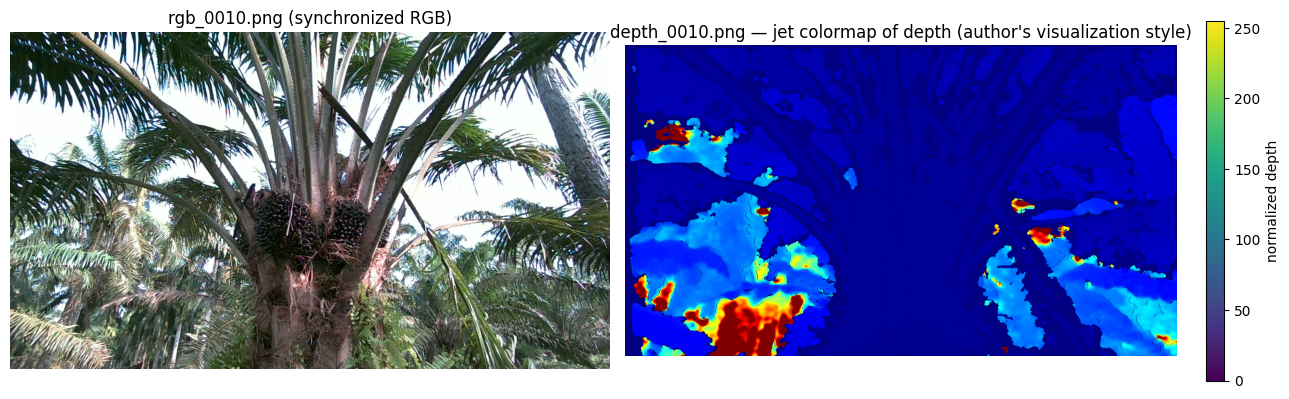

In [ ]:
rgb = cv2.imread(f"/content/ffb_demo/{row.rgb_image}")
rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
depth = cv2.imread(f"/content/ffb_demo/{row.depth_map}", cv2.IMREAD_UNCHANGED)
print("rgb:", rgb.shape, rgb.dtype, " depth:", depth.shape, depth.dtype)
valid = depth[depth < 65535]
print("depth valid pixels:", valid.size, "/", depth.size,
      " range (mm):", int(valid.min()), "-", int(valid.max()))

depth_u8 = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX)
depth_jet = cv2.applyColorMap(depth_u8.astype(np.uint8), cv2.COLORMAP_JET)
depth_jet = cv2.cvtColor(depth_jet, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].imshow(rgb); axes[0].set_title(f"{row.rgb_image} (synchronized RGB)"); axes[0].axis("off")
im1 = axes[1].imshow(depth_jet)
axes[1].set_title(f"{row.depth_map} — jet colormap of depth (author's visualization style)"); axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.03, label="normalized depth")
plt.tight_layout()
plt.savefig("/content/ffb_demo/fig_rgb_depth.png", dpi=110, bbox_inches="tight")
plt.show()

## 9. Parse the released point cloud

The PLY is **ASCII** (header: `element vertex N`, properties `double x/y/z`,
`uchar red/green/blue` — written by Open3D in the authors' released
`capture_localization_data.py` with the 0.5–5.0 m depth clipping and the flip
transform `diag(1, -1, -1, 1)` already applied). We parse it with a header-driven
parser (no `open3d` dependency) and verify the parsed vertex count against the
header. Coordinates are in **metres** in the flipped camera frame
(x right, y up, z backwards).

**日本語:** リリース済みの ASCII PLY（Open3D 生成、フリップ変換適用済み）を
ヘッダ駆動のパーサで読み込み、頂点数をヘッダと照合します。座標はメートル単位です。

In [ ]:
def read_ascii_ply(path):
    with open(path, "rb") as f:
        header = []
        while True:
            line = f.readline().decode("ascii").strip()
            header.append(line)
            if line == "end_header":
                break
    assert header[0] == "ply" and "format ascii 1.0" in header
    n_vertices = int(next(l.split()[-1] for l in header if l.startswith("element vertex")))
    props = [l.split()[-1] for l in header if l.startswith("property")]
    data = np.loadtxt(path, skiprows=len(header))
    assert data.shape[0] == n_vertices, f"header says {n_vertices}, parsed {data.shape[0]}"
    cols = {p: i for i, p in enumerate(props)}
    pts = data[:, [cols["x"], cols["y"], cols["z"]]]
    rgbp = data[:, [cols["red"], cols["green"], cols["blue"]]].astype(np.uint8)
    return pts, rgbp, n_vertices, header

pts, pcolors, n_vertices, header = read_ascii_ply(f"/content/ffb_demo/{row.point_cloud}")
print("vertices:", n_vertices)
print("x range (m): %.2f .. %.2f" % (pts[:, 0].min(), pts[:, 0].max()))
print("y range (m): %.2f .. %.2f" % (pts[:, 1].min(), pts[:, 1].max()))
print("z range (m): %.2f .. %.2f" % (pts[:, 2].min(), pts[:, 2].max()))

vertices: 428408
x range (m): -3.37 .. 4.70
y range (m): -1.38 .. 2.50
z range (m): -4.99 .. -1.07


## 10. DBSCAN parameter selection by silhouette coefficient

The paper's Methods ("Data Annotation and Segmentation (3D)"): *"Run DBSCAN over
point cloud points with epsilon and minPts parameters… Tune parameters iteratively
using the silhouette coefficient to maximize separation and reduce false
positives."* The exact final ε / minPts are **not published** (also flagged in the
PhenoPaper study flow's `missing_or_unclear`), so we implement the paper's
described procedure: a small grid search on a fixed random subsample
(`random_state=0`, 30 000 points), scoring the **silhouette coefficient on
non-noise points** where ≥2 clusters are found. The ε grid is capped at
0.10 m — below the typical FFB diameter (~0.2–0.3 m) — because larger ε
merges neighbouring bunches, contradicting the paper's stated goal of isolating
**individual** FFBs (and makes the full-cloud fit unbounded at this point
density). The winning pair is then applied to the full cloud. Units: ε is in
metres (points are metric).

**日本語:** 論文に記載の通り、DBSCAN の ε / min_samples をシルエット係数で選択します。
固定シードの部分標本（30,000 点）でグリッド探索し、最良の組を全点群に適用します。

In [ ]:
import time
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

rng = np.random.RandomState(0)
GRID_EPS = [0.03, 0.05, 0.08, 0.10]   # metres; capped below FFB diameter (~0.2-0.3 m)
                                      # to keep clusters = individual bunches and runtime bounded
GRID_MIN = [10, 50, 150]                    # min_samples

idx = rng.choice(len(pts), size=min(30000, len(pts)), replace=False)
sub = pts[idx]
print("tuning subsample:", sub.shape)

rows = []
for eps in GRID_EPS:
    for m in GRID_MIN:
        t0 = time.time()
        lab = DBSCAN(eps=eps, min_samples=m).fit_predict(sub)
        mask = lab != -1
        n_c = len(set(lab[mask]))
        sil = silhouette_score(sub[mask], lab[mask]) if n_c >= 2 and mask.sum() > n_c else np.nan
        rows.append((eps, m, n_c, int((~mask).sum()), sil, time.time() - t0))
tune = pandas.DataFrame(rows, columns=["eps_m", "min_samples", "n_clusters", "n_noise", "silhouette", "sec"])
print(tune.to_string(index=False))
ok = tune.dropna(subset=["silhouette"])
assert len(ok), "no (eps, min_samples) produced >=2 clusters; check point cloud"
best = ok.sort_values("silhouette", ascending=False).iloc[0]
BEST_EPS, BEST_MIN = float(best.eps_m), int(best.min_samples)
print(f"selected by silhouette: eps={BEST_EPS} m, min_samples={BEST_MIN} (silhouette={best.silhouette:.3f})")

tuning subsample: (30000, 3)


 eps_m  min_samples  n_clusters  n_noise  silhouette      sec
  0.03           10         181    11952   -0.066594 3.641231
  0.03           50          25    24148    0.223400 0.521520
  0.03          150           0    30000         NaN 0.157553
  0.05           10         213     5342   -0.004511 6.250674
  0.05           50          16    17114   -0.128023 3.825584
  0.05          150           5    26510    0.227160 0.402656
  0.08           10         110     1513   -0.069962 8.344096
  0.08           50          36    11877    0.151360 4.016014
  0.08          150           7    18898    0.107801 1.785412
  0.10           10          71      779   -0.175802 9.191161
  0.10           50          47     8135    0.151312 5.205921
  0.10          150           6    16577   -0.001187 2.367555
selected by silhouette: eps=0.05 m, min_samples=150 (silhouette=0.227)


## 11. Final DBSCAN clustering on the full point cloud

Applies the silhouette-selected parameters to all `n_vertices` points and reports
cluster count, noise fraction, and runtime. This reproduces the paper's
semi-automated clustering step **as a method demonstration**; the authors'
released cluster labels are not part of the public archive, so no quantitative
comparison against them is possible.

**日本語:** 選択されたパラメータで全点群に DBSCAN を適用し、クラスタ数・ノイズ率・
実行時間を報告します。著者のクラスタラベルは公開されていないため定量比較はできません。

In [ ]:
t0 = time.time()
labels = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN).fit_predict(pts)
dt = time.time() - t0
uniq = sorted(set(labels))
n_clusters = len(uniq) - (-1 in uniq)
n_noise = int((labels == -1).sum())
print(f"DBSCAN eps={BEST_EPS} m, min_samples={BEST_MIN} on {len(pts):,} points: "
      f"{n_clusters} clusters, {n_noise:,} noise points ({n_noise/len(pts):.1%}), {dt:.1f} s")
assert n_clusters >= 1, 'DBSCAN found no cluster'

DBSCAN eps=0.05 m, min_samples=150 on 428,408 points: 138 clusters, 88,958 noise points (20.8%), 11.8 s


## 12. Cluster visualization

3-D scatter (matplotlib, static views — no interactive-only output) of a random
subsample of at most 40 000 points, coloured by cluster ID (noise in light grey),
plus the three axis projections. Cluster colours are arbitrary; sizes and
centroids are reported in the table below. This is an **additional visualization
created for this notebook**, not an author figure.

**日本語:** クラスタ ID で着色した 3D 散布図（静的レンダリング）と軸方向投影を表示します。
クラスタ色は任意で、数値は次の表を参照してください。

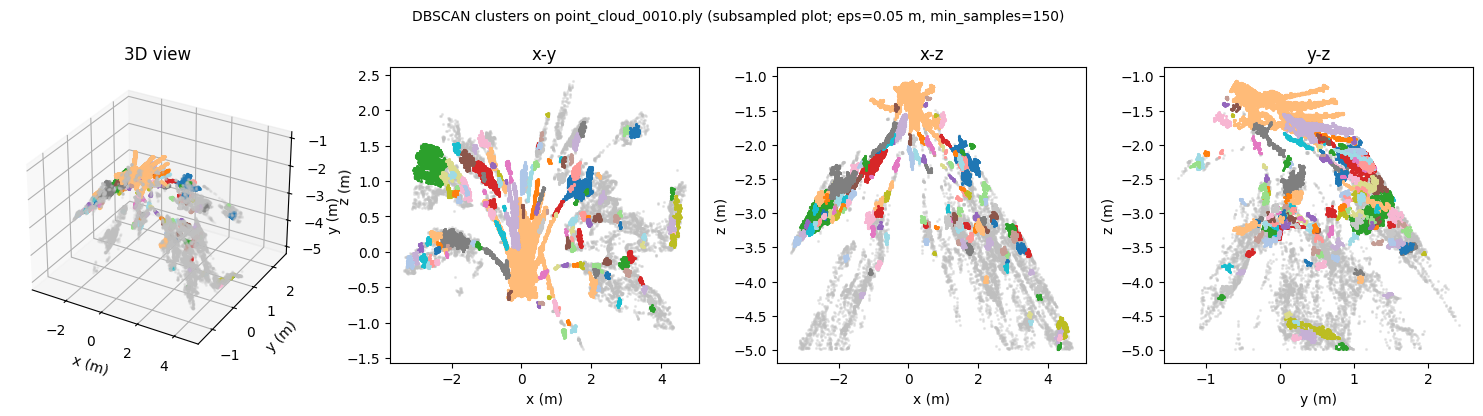

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pidx = rng.choice(len(pts), size=min(40000, len(pts)), replace=False)
pl, pp = labels[pidx], pts[pidx]
cmap = plt.get_cmap("tab20")
colors_map = {-1: (0.75, 0.75, 0.75, 0.3)}
for k in uniq:
    if k != -1:
        colors_map[k] = cmap(((k * 3) % 20) / 20.0)

fig = plt.figure(figsize=(15, 4.2))
ax = fig.add_subplot(1, 4, 1, projection="3d")
for k in uniq:
    m = pl == k
    ax.scatter(pp[m, 0], pp[m, 1], pp[m, 2], s=1.5, c=[colors_map[k]], label=f"c{k}" if k != -1 else "noise")
ax.set_title("3D view"); ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")
views = [("x-y", 0, 1), ("x-z", 0, 2), ("y-z", 1, 2)]
for i, (t, a, b) in enumerate(views):
    axp = fig.add_subplot(1, 4, i + 2)
    for k in uniq:
        m = pl == k
        axp.scatter(pp[m, a], pp[m, b], s=1.5, c=[colors_map[k]])
    axp.set_title(t); axp.set_xlabel(f"{t[0]} (m)"); axp.set_ylabel(f"{t[2]} (m)")
plt.suptitle(f"DBSCAN clusters on {row.point_cloud} (subsampled plot; eps={BEST_EPS} m, min_samples={BEST_MIN})", fontsize=10)
plt.tight_layout()
plt.savefig("/content/ffb_demo/fig_clusters.png", dpi=110, bbox_inches="tight")
plt.show()

## 13. Results table and CSV export

Per-cluster summary: point count, centroid `(x, y, z)` in metres (equation (4) of
the paper — the arithmetic mean of member coordinates, which is exactly how the
authors define cluster centroids), and mean observed colour. The table is also
written to `/content/ffb_cluster_summary.csv` for download.

**日本語:** 各クラスタの点数・重心（論文式(4)どおりのメンバー座標の算術平均）・平均色を
表と CSV（`/content/ffb_cluster_summary.csv`）に出力します。

In [ ]:
summary = []
for k in uniq:
    if k == -1:
        continue
    m = labels == k
    summary.append({
        "cluster_id": k,
        "n_points": int(m.sum()),
        "centroid_x_m": round(float(pts[m, 0].mean()), 4),
        "centroid_y_m": round(float(pts[m, 1].mean()), 4),
        "centroid_z_m": round(float(pts[m, 2].mean()), 4),
        "mean_R": int(pcolors[m, 0].mean()),
        "mean_G": int(pcolors[m, 1].mean()),
        "mean_B": int(pcolors[m, 2].mean()),
    })
summary_df = pandas.DataFrame(summary).sort_values("n_points", ascending=False).reset_index(drop=True)
print(summary_df.to_string(index=False))
summary_df.to_csv("/content/ffb_cluster_summary.csv", index=False)
print("saved /content/ffb_cluster_summary.csv")

 cluster_id  n_points  centroid_x_m  centroid_y_m  centroid_z_m  mean_R  mean_G  mean_B
          1    189698        0.0461       -0.0888       -1.3498      70      77      81
          3     16125       -0.2300        0.4464       -1.7441     123     123     117
          8     15841       -2.6188        1.2340       -3.0104      88      89      72
          0     11364        1.6021        0.9436       -2.1530     118     117     102
          2      9484       -0.9981        1.0652       -2.2693      51      65      45
         78      7821       -1.9571        0.1877       -2.5587      68      78      62
         98      4903       -0.6192       -0.1666       -1.8883      65      71      65
          7      2993        0.0405        1.0309       -2.1368     178     185     182
         10      2884       -1.5736        1.3000       -2.6018     170     161     141
         14      2727        0.3828        0.7684       -1.8964     109     110     108
         19      2673       -1.9

## Interpretation, differences from the paper, and validation record

**What was executed (Colab CPU VM, 2026-10-08):** structure verification against
paper Table 4; extraction and rendering of one COCO-annotated ripeness JPEG with
its reference expert polygons; extraction of one synchronized
RGB + depth + released PLY capture; DBSCAN over the released point cloud with
ε / min_samples chosen by silhouette coefficient as the paper describes.

**Differences / limitations (EN + 日本語):**

- The paper releases **no classifier/detector/weights**; nothing here estimates
  ripeness — the overlay shows the dataset's own reference labels only.
  （本論文には分類器・検出器・重みが存在しないため、熟度推定は行いません。）
- DBSCAN ε/min_samples are **our selection** via the paper's silhouette procedure;
  the authors' final values are unpublished.
  （DBSCAN のパラメータは未公表のため、論文記載の手順に従い本ノートブックで選択しました。）
- The clustering result on one capture is a **method demonstration**; the authors'
  released dataset contains no cluster ground truth to compare against, and one
  example does not validate dataset-level statistics.
  （1 サンプルの実行は手法デモであり、データセット全体の統計検証ではありません。）
- RGB–depth calibration matrices are not applied (per-image intrinsics are not in
  `metadata.csv`), so 3D centroids are not projected onto the RGB image.
  （キャリブレーション行列が metadata.csv にないため、3D 重心の RGB への投影は行いません。）
- Only ~25 MB of the 4.3 GB archive is downloaded via HTTP range requests;
  extracted members are CRC-verified by `zipfile`.
  （4.3 GB のうち約 25 MB のみ取得し、抽出メンバーは CRC 検証済みです。）

**References**

- Goh et al., *Scientific Data* 12, 687 (2025). https://doi.org/10.1038/s41597-025-04953-6
- Dataset: oilpalm-ffb-dataset v2, figshare, CC BY 4.0. https://doi.org/10.6084/m9.figshare.28574489.v2
- Released scripts (same figshare item): `ffb_data_collection.py`, `opencv_pc.py`
  (= `capture_localization_data.py`), `stitching.py`.
- DBSCAN: Ester et al. (1996); silhouette: Rousseeuw (1987); implementation:
  scikit-learn.